### 1. Data Loading and Initial Exploration
Loading the 13 raw CSV files into a single Spark DataFrame and inspecting the schema.

In [1]:
from pyspark.sql import SparkSession

# Initialize the Spark Session
spark = SparkSession.builder \
    .appName("GasSensorAnalysis") \
    .config("spark.driver.memory", "8g") \
    .config("spark.sql.shuffle.partitions", "10") \
    .getOrCreate()

print("Spark started successfully!")

# Load the entire folder containing the CSV files
folder_path = "data/*.csv" 

# Read the CSVs
df = spark.read.csv(folder_path, header=True, inferSchema=True) 

print(f"Loaded {df.count()} total records from all files!")

# Show the column names
df.printSchema()

# Show the first 5 rows
df.show(5)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/19 14:47:37 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark started successfully!


26/03/19 14:47:40 WARN FileStreamSink: Assume no metadata directory. Error while looking for metadata directory in the path: data/*.csv.
java.io.FileNotFoundException: File data/*.csv does not exist
	at org.apache.hadoop.fs.RawLocalFileSystem.deprecatedGetFileStatus(RawLocalFileSystem.java:980)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileLinkStatusInternal(RawLocalFileSystem.java:1301)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileStatus(RawLocalFileSystem.java:970)
	at org.apache.hadoop.fs.FilterFileSystem.getFileStatus(FilterFileSystem.java:462)
	at org.apache.spark.sql.execution.streaming.sinks.FileStreamSink$.hasMetadata(FileStreamSink.scala:58)
	at org.apache.spark.sql.execution.datasources.DataSource.resolveRelation(DataSource.scala:384)
	at org.apache.spark.sql.catalyst.analysis.ResolveDataSource.org$apache$spark$sql$catalyst$analysis$ResolveDataSource$$loadV1BatchSource(ResolveDataSource.scala:143)
	at org.apache.spark.sql.catalyst.analysis.ResolveDataSource$$anonfu

Loaded 3843160 total records from all files!
root
 |-- Time (s): double (nullable = true)
 |-- CO (ppm): double (nullable = true)
 |-- Humidity (%r.h.): double (nullable = true)
 |-- Temperature (C): double (nullable = true)
 |-- Flow rate (mL/min): double (nullable = true)
 |-- Heater voltage (V): double (nullable = true)
 |-- R1 (MOhm): double (nullable = true)
 |-- R2 (MOhm): double (nullable = true)
 |-- R3 (MOhm): double (nullable = true)
 |-- R4 (MOhm): double (nullable = true)
 |-- R5 (MOhm): double (nullable = true)
 |-- R6 (MOhm): double (nullable = true)
 |-- R7 (MOhm): double (nullable = true)
 |-- R8 (MOhm): double (nullable = true)
 |-- R9 (MOhm): double (nullable = true)
 |-- R10 (MOhm): double (nullable = true)
 |-- R11 (MOhm): double (nullable = true)
 |-- R12 (MOhm): double (nullable = true)
 |-- R13 (MOhm): double (nullable = true)
 |-- R14 (MOhm): double (nullable = true)

+--------+--------+----------------+---------------+------------------+------------------+-----

### 2. Data Transformation (Unpivot) & Timestamp Normalization
Converting the wide-format sensor columns into a long format using `stack` and generating a 5-minute interval timeseries per sensor. Also includes a missing values check.

In [2]:
from pyspark.sql.functions import col, expr, row_number, count, isnan, when
from pyspark.sql.window import Window

# Unpivot - Convert the 14 sensor columns into 2 (Sensor_ID, Resistance)
unpivot_expr = "stack(14, " + ", ".join([f"'R{i}', `R{i} (MOhm)`" for i in range(1, 15)]) + ") as (Sensor_ID, Resistance)"

# Using backticks (`) around column names to prevent PySpark from misinterpreting dots (.)
df_melted = df.select(
    col("`Time (s)`"),
    col("`CO (ppm)`"),
    col("`Humidity (%r.h.)`"),
    col("`Temperature (C)`"),
    col("`Flow rate (mL/min)`"),
    col("`Heater voltage (V)`"),
    expr(unpivot_expr)
)

print("Unpivot complete!")

# Timestamp Normalization (Per sensor, starting 2025-09-01, 5-minute intervals)
window_spec = Window.partitionBy("Sensor_ID").orderBy(col("`Time (s)`"))

# Create row number (0, 1, 2...) for each measurement of the same sensor
df_normalized = df_melted.withColumn("row_num", row_number().over(window_spec) - 1)

# Calculate the new timestamp
df_normalized = df_normalized.withColumn(
    "Timestamp",
    expr("timestamp('2025-09-01 00:00:00') + interval 5 minutes * row_num")
).drop("row_num")

print("Timestamp normalization complete!")

# Check for Missing Values
print("Checking for missing values per column:")

missing_exprs = []
for c_name, c_type in df_normalized.dtypes:
    safe_c = f"`{c_name}`"
    
    if c_type in ('double', 'float', 'int', 'bigint'):
        # For numbers: check NaN and Null
        missing_exprs.append(count(when(isnan(col(safe_c)) | col(safe_c).isNull(), c_name)).alias(c_name))
    else:
        # For Strings: check only Null
        missing_exprs.append(count(when(col(safe_c).isNull(), c_name)).alias(c_name))

missing_counts = df_normalized.select(missing_exprs)
missing_counts.show()

# Show final result
df_normalized.show(5)

Unpivot complete!
Timestamp normalization complete!
Checking for missing values per column:


26/03/19 14:47:48 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+--------+--------+----------------+---------------+------------------+------------------+---------+----------+---------+
|Time (s)|CO (ppm)|Humidity (%r.h.)|Temperature (C)|Flow rate (mL/min)|Heater voltage (V)|Sensor_ID|Resistance|Timestamp|
+--------+--------+----------------+---------------+------------------+------------------+---------+----------+---------+
|       0|       0|               0|              0|                 0|                 0|        0|         0|        0|
+--------+--------+----------------+---------------+------------------+------------------+---------+----------+---------+



+--------+--------+----------------+---------------+------------------+------------------+---------+----------+-------------------+
|Time (s)|CO (ppm)|Humidity (%r.h.)|Temperature (C)|Flow rate (mL/min)|Heater voltage (V)|Sensor_ID|Resistance|          Timestamp|
+--------+--------+----------------+---------------+------------------+------------------+---------+----------+-------------------+
|     0.0|     0.0|         54.6258|        25.3178|          242.5724|             0.203|      R12|   62.2197|2025-09-01 00:00:00|
|     0.0|     0.0|           57.71|          25.74|          243.7841|            0.1996|      R12|    43.306|2025-09-01 00:05:00|
|     0.0|     0.0|         51.0811|        26.1138|          244.9963|            0.8985|      R12|    0.0611|2025-09-01 00:10:00|
|     0.0|     0.0|           48.47|          24.62|          247.4926|               0.2|      R12|   51.8182|2025-09-01 00:15:00|
|     0.0|     0.0|         63.0844|        25.3805|          242.4995|     

### 3. Exploratory Data Analysis & Outlier Detection
Visualizing the distributions of key variables (Resistance, Heater Voltage, CO, Humidity) using a 1% sample to identify potential outliers.

Taking a 1% random sample


Sample ready! Plotting graphs...


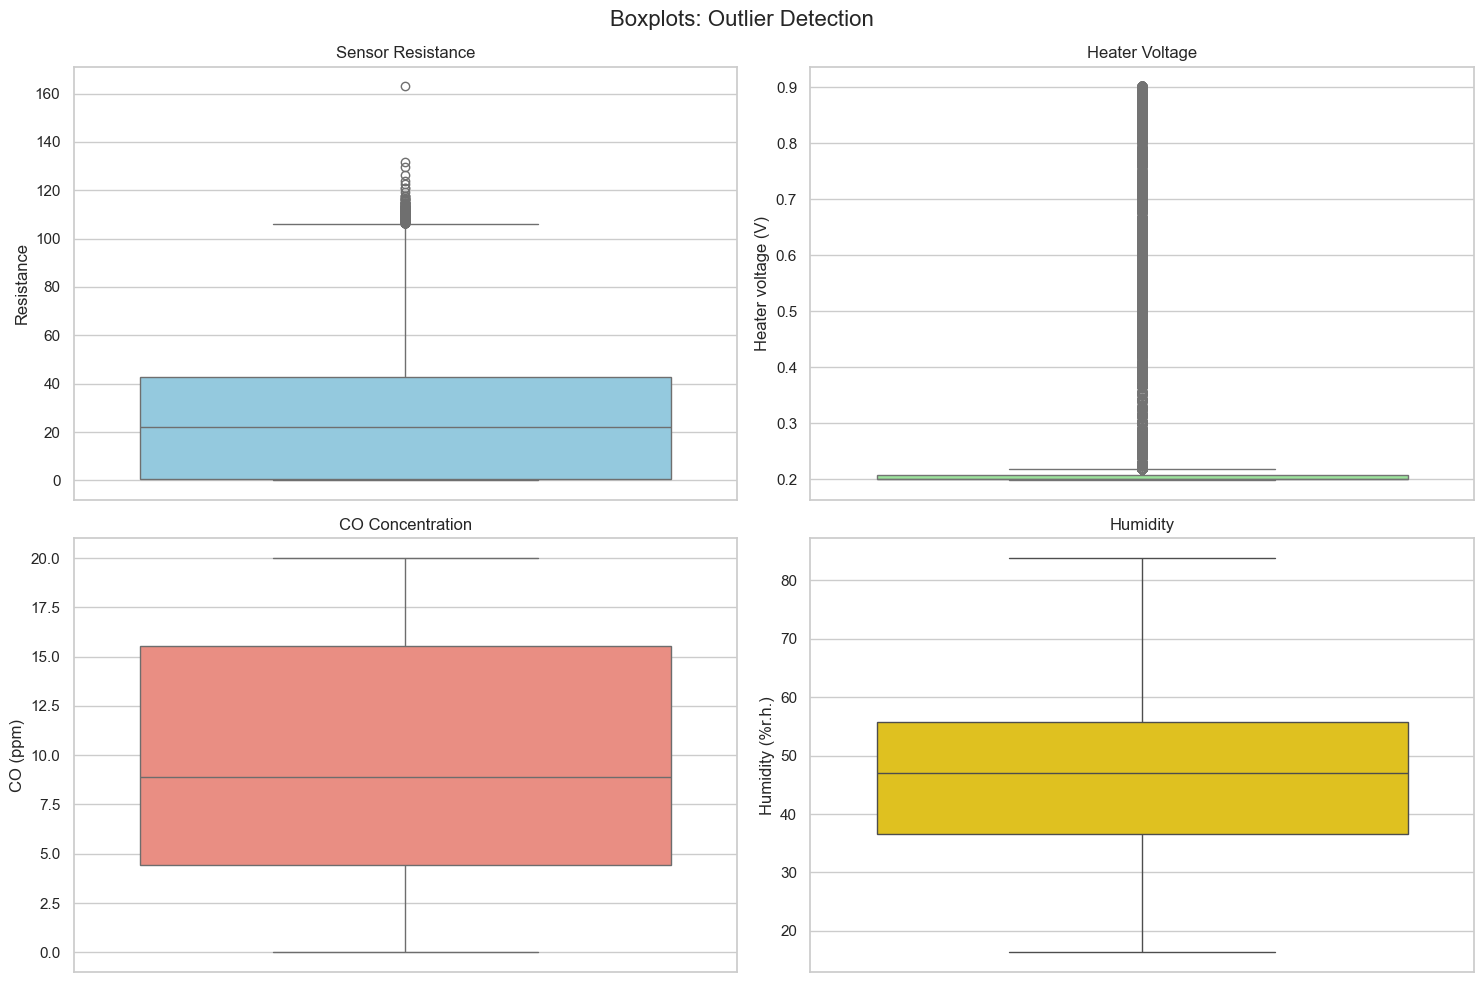

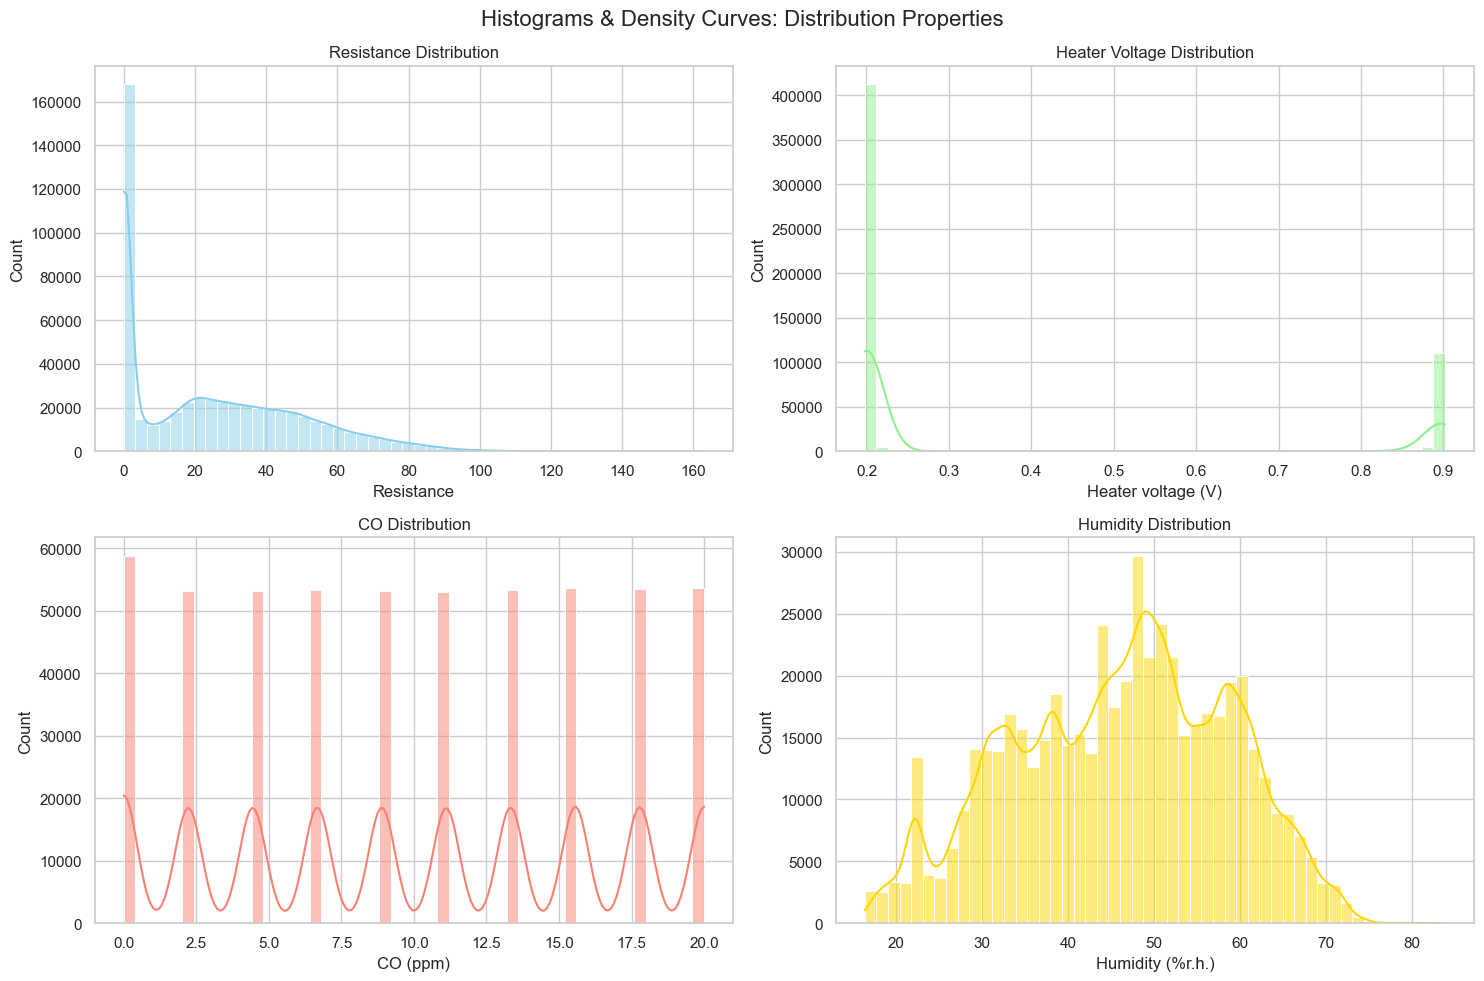

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Taking a 1% random sample")
df_sample = df_normalized.select(
    "Resistance", 
    "`Heater voltage (V)`", 
    "`CO (ppm)`", 
    "`Humidity (%r.h.)`"
).sample(fraction=0.01, seed=42).toPandas()

print("Sample ready! Plotting graphs...")

# Set plot style
sns.set_theme(style="whitegrid")

# Boxplots for Outlier Detection
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Boxplots: Outlier Detection", fontsize=16)

sns.boxplot(y=df_sample["Resistance"], ax=axes[0, 0], color="skyblue").set_title("Sensor Resistance")
sns.boxplot(y=df_sample["Heater voltage (V)"], ax=axes[0, 1], color="lightgreen").set_title("Heater Voltage")
sns.boxplot(y=df_sample["CO (ppm)"], ax=axes[1, 0], color="salmon").set_title("CO Concentration")
sns.boxplot(y=df_sample["Humidity (%r.h.)"], ax=axes[1, 1], color="gold").set_title("Humidity")

plt.tight_layout()
plt.show()

# Histograms & Density Curves
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Histograms & Density Curves: Distribution Properties", fontsize=16)

sns.histplot(df_sample["Resistance"], bins=50, kde=True, ax=axes[0, 0], color="skyblue").set_title("Resistance Distribution")
sns.histplot(df_sample["Heater voltage (V)"], bins=50, kde=True, ax=axes[0, 1], color="lightgreen").set_title("Heater Voltage Distribution")
sns.histplot(df_sample["CO (ppm)"], bins=50, kde=True, ax=axes[1, 0], color="salmon").set_title("CO Distribution")
sns.histplot(df_sample["Humidity (%r.h.)"], bins=50, kde=True, ax=axes[1, 1], color="gold").set_title("Humidity Distribution")

plt.tight_layout()
plt.show()

### 4. (i): Total CO Concentration for High Heater Voltage
Calculating the sum of CO (ppm) for records where the Heater Voltage exceeds 60% of its maximum value.

In [4]:
from pyspark.sql.functions import max as spark_max, sum as spark_sum, col

# Find the maximum heater voltage in the dataset
max_voltage = df_normalized.select(spark_max("`Heater voltage (V)`")).collect()[0][0]
print(f"Maximum Heater Voltage: {max_voltage} V")

# Calculate the 60% threshold
threshold = 0.60 * max_voltage
print(f"60% Threshold: {threshold} V")

# Filter the dataframe and calculate the total sum of CO
total_co = df_normalized.filter(col("`Heater voltage (V)`") > threshold) \
                        .select(spark_sum("`CO (ppm)`")).collect()[0][0]

print(f"Total CO concentration for these records: {total_co:.2f} ppm")

Maximum Heater Voltage: 0.9026 V
60% Threshold: 0.5415599999999999 V


Total CO concentration for these records: 118381886.75 ppm


### 5. (ii): Mean and Variance of Resistance per Sensor
Grouping the data by `Sensor_ID` to calculate the mean and variance of the resistance measurements.

In [5]:
from pyspark.sql.functions import mean, variance, round

print("ii) Calculate mean and variance of Resistance per sensor")

# Group by Sensor_ID and calculate mean and variance for Resistance
df_sensor_stats = df_normalized.groupBy("Sensor_ID") \
    .agg(
        round(mean("Resistance"), 4).alias("Mean_Resistance"),
        round(variance("Resistance"), 4).alias("Variance_Resistance")
    ) \
    .orderBy("Sensor_ID") # Order alphabetically so the table looks clean

# Show results for 14 sensors
df_sensor_stats.show(14)

ii) Calculate mean and variance of Resistance per sensor


+---------+---------------+-------------------+
|Sensor_ID|Mean_Resistance|Variance_Resistance|
+---------+---------------+-------------------+
|       R1|        16.4147|           571.8817|
|      R10|        26.1684|           438.2867|
|      R11|        28.3357|           447.6781|
|      R12|        26.2942|           375.2663|
|      R13|        23.2836|           326.5254|
|      R14|        29.1988|            511.541|
|       R2|        18.4712|           762.8813|
|       R3|        23.0373|           853.1205|
|       R4|         21.445|           315.7909|
|       R5|        32.6218|           775.5215|
|       R6|        29.5649|            769.961|
|       R7|        32.8193|           796.4055|
|       R8|        27.9932|           423.7335|
|       R9|         23.686|           352.0438|
+---------+---------------+-------------------+



### 6. (iii): Accumulator for Environmental Conditions
Using a Spark Accumulator to count instances where CO > 10 ppm and Humidity < 30 %r.h. based on the original dataframe.

In [6]:
# Create the accumulator with an initial value of 0
condition_accumulator = spark.sparkContext.accumulator(0)

# Define a function to check each row individually
def check_conditions(row):
    co_val = row["CO (ppm)"]
    hum_val = row["Humidity (%r.h.)"]
    
    if co_val > 10.0 and hum_val < 30.0:
        condition_accumulator.add(1)

# Apply the function to each row of the original dataframe
print("Calculating accumulator...")
df.foreach(check_conditions)

# Print the final value of the accumulator
print(f"Final Accumulator Value: {condition_accumulator.value}")

Calculating accumulator...


Final Accumulator Value: 302529


### 7. (iv): Recalculate Resistance and Reduce by Key

In [7]:
from pyspark.sql.functions import col, max as spark_max

# Create new column 'R' using the formula R = ((5 - V) / V) * 1,000,000
df_calc = df_normalized.withColumn(
    "R", 
    ((5 - col("`Heater voltage (V)`")) / col("`Heater voltage (V)`")) * 1000000
)

# Perform key-based reduction
df_reduced = df_calc.groupBy("`Heater voltage (V)`") \
                    .agg(spark_max("R").alias("Max_R")) \
                    .orderBy("`Heater voltage (V)`")

# Show results
df_reduced.show()

+------------------+--------------------+
|Heater voltage (V)|               Max_R|
+------------------+--------------------+
|             0.198|2.4252525252525248E7|
|            0.1981|2.4239777889954567E7|
|            0.1982|2.4227043390514635E7|
|            0.1983|2.4214321734745335E7|
|            0.1984|2.4201612903225806E7|
|            0.1985|2.4188916876574308E7|
|            0.1986| 2.417623363544814E7|
|            0.1987|2.4163563160543535E7|
|            0.1988|2.4150905432595573E7|
|            0.1989| 2.413826043237808E7|
|             0.199|2.4125628140703518E7|
|            0.1991|2.4113008538422905E7|
|            0.1992|2.4100401606425703E7|
|            0.1993|2.4087807325639736E7|
|            0.1994|2.4075225677031096E7|
|            0.1995|2.4062656641604006E7|
|            0.1996|2.4050100200400803E7|
|            0.1997|2.4037556334501754E7|
|            0.1998|2.4025025025025025E7|
|            0.1999| 2.401250625312656E7|
+------------------+--------------

### 8. (v): 25-Minute Window Analysis for a Specific Sensor

In [8]:
from pyspark.sql.functions import col, window, mean as spark_mean, round

# Filter the dataset for sensor R1
sensor_id = 'R1'
df_r1 = df_normalized.filter(col("Sensor_ID") == sensor_id)

# Define the 25-minute window and calculate the mean of CO and humidity
df_windowed = df_r1.groupBy(window(col("Timestamp"), "25 minutes")) \
                   .agg(
                       round(spark_mean("`CO (ppm)`"), 4).alias("Mean_CO"),
                       round(spark_mean("`Humidity (%r.h.)`"), 4).alias("Mean_Humidity")
                   ) \
                   .orderBy("window.start") # Chronological order

# Show results
df_windowed.select("window.start", "window.end", "Mean_CO", "Mean_Humidity").show(10, truncate=False)

+-------------------+-------------------+-------+-------------+
|start              |end                |Mean_CO|Mean_Humidity|
+-------------------+-------------------+-------+-------------+
|2025-09-01 00:00:00|2025-09-01 00:25:00|0.0    |54.9943      |
|2025-09-01 00:25:00|2025-09-01 00:50:00|0.0    |50.3395      |
|2025-09-01 00:50:00|2025-09-01 01:15:00|0.0    |47.1924      |
|2025-09-01 01:15:00|2025-09-01 01:40:00|0.0    |49.446       |
|2025-09-01 01:40:00|2025-09-01 02:05:00|0.0    |54.1773      |
|2025-09-01 02:05:00|2025-09-01 02:30:00|0.0    |52.4588      |
|2025-09-01 02:30:00|2025-09-01 02:55:00|0.0    |53.2936      |
|2025-09-01 02:55:00|2025-09-01 03:20:00|0.0    |54.6465      |
|2025-09-01 03:20:00|2025-09-01 03:45:00|0.0    |52.512       |
|2025-09-01 03:45:00|2025-09-01 04:10:00|0.0    |51.8144      |
+-------------------+-------------------+-------+-------------+
only showing top 10 rows


### 9. Feature Engineering: Transition to Pandas
Aggregating the 14 sensors into a single Mean Resistance per timestamp to 
convert the Big Data Spark DataFrame into a Pandas DataFrame.

In [9]:
from pyspark.sql.functions import mean as spark_mean

# Group by Timestamp and all other environmental variables and compress the 14 rows into 1
df_grouped = df_normalized.groupBy(
    "Timestamp", "`Temperature (C)`", "`Heater voltage (V)`", "`CO (ppm)`"
).agg(
    spark_mean("Resistance").alias("Mean_Resistance")
).orderBy("Timestamp")

# Convert to Pandas
pdf = df_grouped.toPandas()

print(f"Successfully converted! Pandas DataFrame shape: {pdf.shape}")

Successfully converted! Pandas DataFrame shape: (3913626, 5)


### 10. New Features & Rolling Average Visualization
Creating new features (Temperature Difference, Heater Phase) and plotting Mean Resistance against a 25-minute rolling average of CO.

,Timestamp,Mean_Resistance,Temp_Diff,Heater_Phase,CO_Rolling_25min
0,2025-09-01 00:00:00,0.11870,0.0000,High,0.0
1,2025-09-01 00:00:00,59.11695,-1.1422,Low,0.0
2,2025-09-01 00:00:00,1.43090,-1.5994,High,0.0
3,2025-09-01 00:05:00,75.79150,1.5994,Low,0.0
4,2025-09-01 00:05:00,3.40185,-1.5994,High,0.0


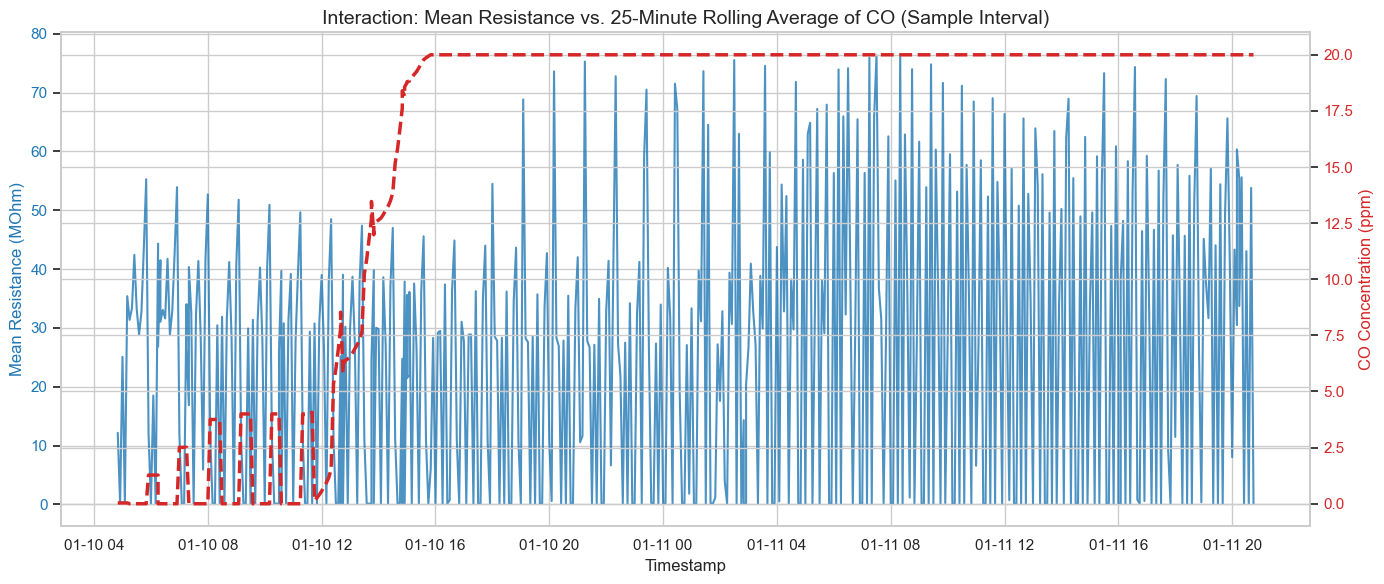

In [10]:
import numpy as np
import matplotlib.pyplot as plt

#: Temperature difference between consecutive time steps
pdf['Temp_Diff'] = pdf['Temperature (C)'].diff().fillna(0)

# Feature 3:  --- Creating new features ---
# (Mean Resistance already created in previous step)

pdf = pdf.sort_values("Timestamp").reset_index(drop=True)

# Feature 2Categorical label for heater phase
pdf['Heater_Phase'] = np.where(pdf['Heater voltage (V)'] > 0.5, 'High', 'Low')

# Feature 4: 25-minute rolling average for CO
pdf['CO_Rolling_25min'] = pdf['CO (ppm)'].rolling(window=5, min_periods=1).mean()

display(pdf[['Timestamp', 'Mean_Resistance', 'Temp_Diff', 'Heater_Phase', 'CO_Rolling_25min']].head())

# --- Visualization ---

# Isolate a 500-record sample window starting at the first instance of gas exposure (CO > 0)
exposure_start_idx = pdf[pdf['CO (ppm)'] > 0].index[0] if not pdf[pdf['CO (ppm)'] > 0].empty else 1000
pdf_plot = pdf.iloc[exposure_start_idx : exposure_start_idx + 500]

fig, ax1 = plt.subplots(figsize=(14, 6))

# Left Y-axis (Resistance)
color1 = 'tab:blue'
ax1.set_xlabel('Timestamp')
ax1.set_ylabel('Mean Resistance (MOhm)', color=color1)
ax1.plot(pdf_plot['Timestamp'], pdf_plot['Mean_Resistance'], color=color1, alpha=0.8, label='Mean Resistance')
ax1.tick_params(axis='y', labelcolor=color1)

# Right Y-axis (CO Rolling Average)
ax2 = ax1.twinx()  
color2 = 'tab:red'
ax2.set_ylabel('CO Concentration (ppm)', color=color2)  
ax2.plot(pdf_plot['Timestamp'], pdf_plot['CO_Rolling_25min'], color=color2, linestyle='--', linewidth=2.5, label='CO (25-min Rolling)')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Interaction: Mean Resistance vs. 25-Minute Rolling Average of CO (Sample Interval)', fontsize=14)
fig.tight_layout()  
plt.show()

### 11. Temporal Analysis: STL Decomposition
Applying Seasonal-Trend decomposition using LOESS (STL) to the mean resistance time series to isolate Trend, Seasonal, and Residual components.

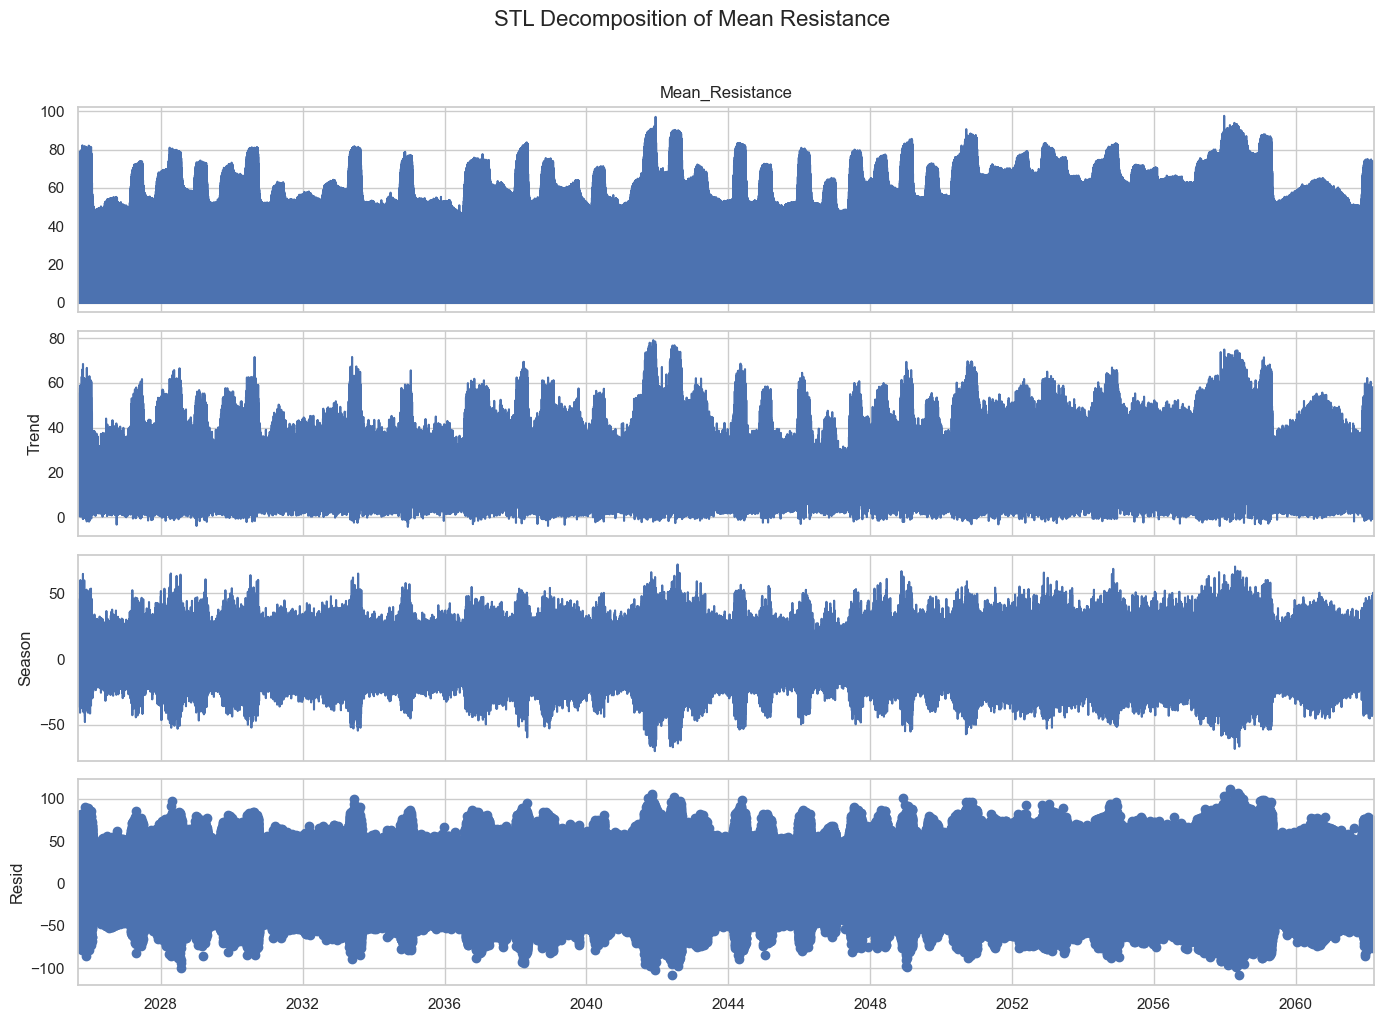

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

# Calculate the mean resistance per timestamp
# (This ensures a clean time series without duplicate entries)
ts_data = pdf.groupby('Timestamp')['Mean_Resistance'].mean().dropna()

# Apply STL decomposition.
# period=12: assuming patterns repeat every 1 hour (12 x 5 minutes)
stl = STL(ts_data, period=12, robust=True)
res = stl.fit()

# Visualization
fig = res.plot()
fig.set_size_inches(14, 10)
plt.suptitle('STL Decomposition of Mean Resistance', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Save the residuals
residuals = res.resid.dropna()

### 12. Autocorrelation (ACF) & Partial Autocorrelation (PACF) Functions
Applying the ACF and PACF on the residual component of the STL model to determine the system's "memory length" (how much the current state is influenced by previous measurements)

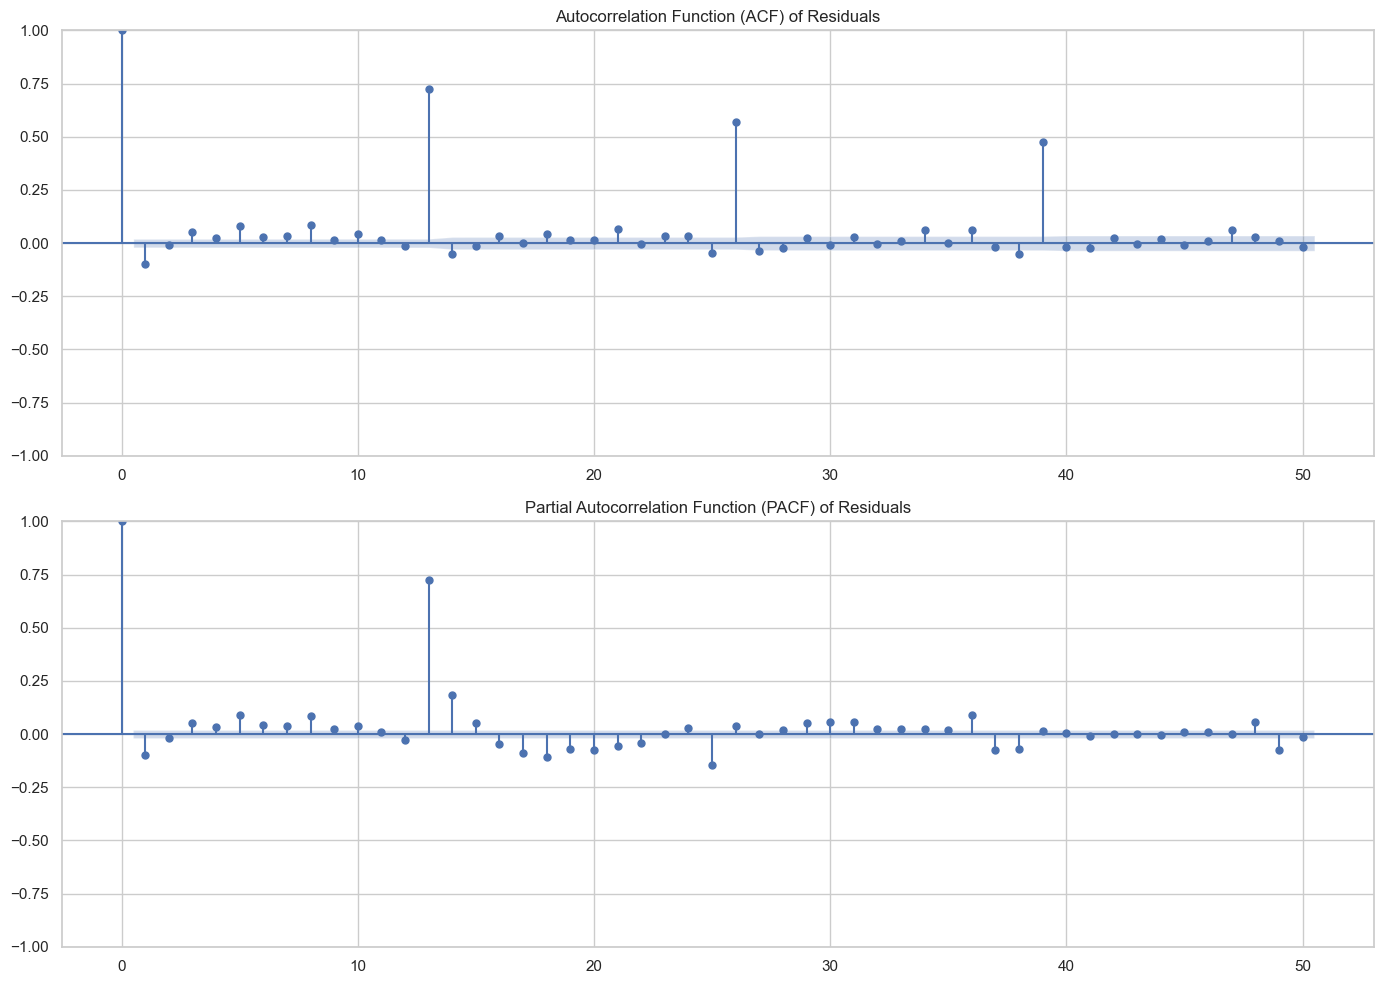

In [12]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
sample_residuals = residuals[:10000]

# Plot ACF (with alpha=0.05 for the 95% confidence interval)
plot_acf(sample_residuals, ax=ax1, lags=50, alpha=0.05, title='Autocorrelation Function (ACF) of Residuals')

# Plot PACF
plot_pacf(sample_residuals, ax=ax2, lags=50, alpha=0.05, title='Partial Autocorrelation Function (PACF) of Residuals')

plt.tight_layout()
plt.show()

### 13. Stationarity Test
Applying the ADF statistical test on the residual component of the STL model to verify if the noise time series is stationary

In [13]:
from statsmodels.tsa.stattools import adfuller

sample_residuals = residuals[:10000]

# ADF test
adf_result = adfuller(sample_residuals)
test_statistic = adf_result[0]
p_value = adf_result[1]

print("-" * 40)
print(f"ADF Test Statistic: {test_statistic:.4f}")
print(f"p-value: {p_value:.4e}")
print("-" * 40)

if p_value < 0.05:
    print("Result: Reject the null hypothesis.")
    print("The residual series is STATIONARY (No unit root present).")
else:
    print("Result: Fail to reject the null hypothesis.")
    print("The residual series is NON-STATIONARY (Unit root is present).")

----------------------------------------
ADF Test Statistic: -8.8023
p-value: 2.0961e-14
----------------------------------------
Result: Reject the null hypothesis.
The residual series is STATIONARY (No unit root present).


### 14. Feature Engineering and Chronological Data Splitting (70-20-10)
In this step, we engineer new features based on the ACF results and recaclulate the features from our previous feature engineering in the pandas environment. After that we split the data for training, validation and testing.

The new features are `lag_1` (t-1) and `lag_13` (t-13) to capture the short-term and cyclical memory of the system.

From Pandas: the temperature difference (`Temp_Diff`), a binary indicator for the heater status (`Heater_Phase`), and a 25-minute rolling average for CO emissions (`CO_Rolling_25min`)

In [14]:
from pyspark.sql import Window
from pyspark.sql.functions import col, lag, percent_rank, when, avg

# Define Windows for calculations per sensor
window_spec = Window.partitionBy("Sensor_ID").orderBy("Timestamp")

# Recalculate features + Calculate new
df_features = df_normalized \
    .withColumn("Temp_Diff", col("`Temperature (C)`") - lag("`Temperature (C)`", 1).over(window_spec)) \
    .withColumn("Heater_Phase", when(col("`Heater voltage (V)`") > 0.5, 1).otherwise(0)) \
    .withColumn("CO_Rolling_25min", avg("`CO (ppm)`").over(
        Window.partitionBy("Sensor_ID").orderBy("Timestamp").rowsBetween(-4, Window.currentRow)
    )) \
    .withColumn("lag_1", lag("Resistance", 1).over(window_spec)) \
    .withColumn("lag_13", lag("Resistance", 13).over(window_spec))

# Fill null values
df_features = df_features.fillna(0, subset=["Temp_Diff"])

# Drop the first 13 rows (null)
df_features = df_features.na.drop(subset=["lag_1", "lag_13"])

# Calculate chronological rank
df_ranked = df_features.withColumn("rank", percent_rank().over(window_spec))

# Split the dataset based on the rank
train_data = df_ranked.filter(col("rank") <= 0.70).drop("rank")
val_data = df_ranked.filter((col("rank") > 0.70) & (col("rank") <= 0.90)).drop("rank")
test_data = df_ranked.filter(col("rank") > 0.90).drop("rank")

# Cache datasets
train_data.cache()
val_data.cache()
test_data.cache()

# Print split results
print(f"Training Set Count (70%): {train_data.count()} rows")
print(f"Validation Set Count (20%): {val_data.count()} rows")
print(f"Testing Set Count (10%): {test_data.count()} rows")

# Show a sample
train_data.select("Sensor_ID", "Timestamp", "Resistance", "Temp_Diff", "Heater_Phase", "CO_Rolling_25min", "lag_1", "lag_13").show(5)

26/03/19 15:00:12 WARN MemoryStore: Not enough space to cache rdd_126_2 in memory! (computed 584.2 MiB so far)
26/03/19 15:00:12 WARN BlockManager: Persisting block rdd_126_2 to disk instead.


Training Set Count (70%): 37662842 rows


Validation Set Count (20%): 10760806 rows


Testing Set Count (10%): 5380410 rows


+---------+-------------------+----------+-------------------+------------+----------------+-------+-------+
|Sensor_ID|          Timestamp|Resistance|          Temp_Diff|Heater_Phase|CO_Rolling_25min|  lag_1| lag_13|
+---------+-------------------+----------+-------------------+------------+----------------+-------+-------+
|      R12|2025-09-01 01:05:00|    0.1025| 3.8965999999999994|           1|             0.0| 0.1009|62.2197|
|      R12|2025-09-01 01:10:00|   42.2283| 11.940199999999999|           0|             0.0| 0.1025| 43.306|
|      R12|2025-09-01 01:15:00|    4.3962| 0.3200000000000003|           1|             0.0|42.2283| 0.0611|
|      R12|2025-09-01 01:20:00|    6.2089|-0.2799999999999976|           0|             0.0| 4.3962|51.8182|
|      R12|2025-09-01 01:25:00|   50.3466| 0.5199999999999996|           0|             0.0| 6.2089|60.8831|
+---------+-------------------+----------+-------------------+------------+----------------+-------+-------+
only showing top 5 